## Análise Exploratória de Dados

Nesta secção, é feita a análise do conjunto de dados que foi anteriormente lido e processado, com o objetivo de compreender as distribuições entre variáveis, identificar correlações e padrões relevantes a previsão do sucesso das dietas feitas.

In [3]:
from functions.read_data import read_data
from functions.data_processing import data_processing

df_raw = read_data()
df = data_processing(df_raw)

print(df_raw.shape)
print(df.shape)

(2523, 30)
(1993, 25)


#### **Distribuição das Variáveis Numéricas**

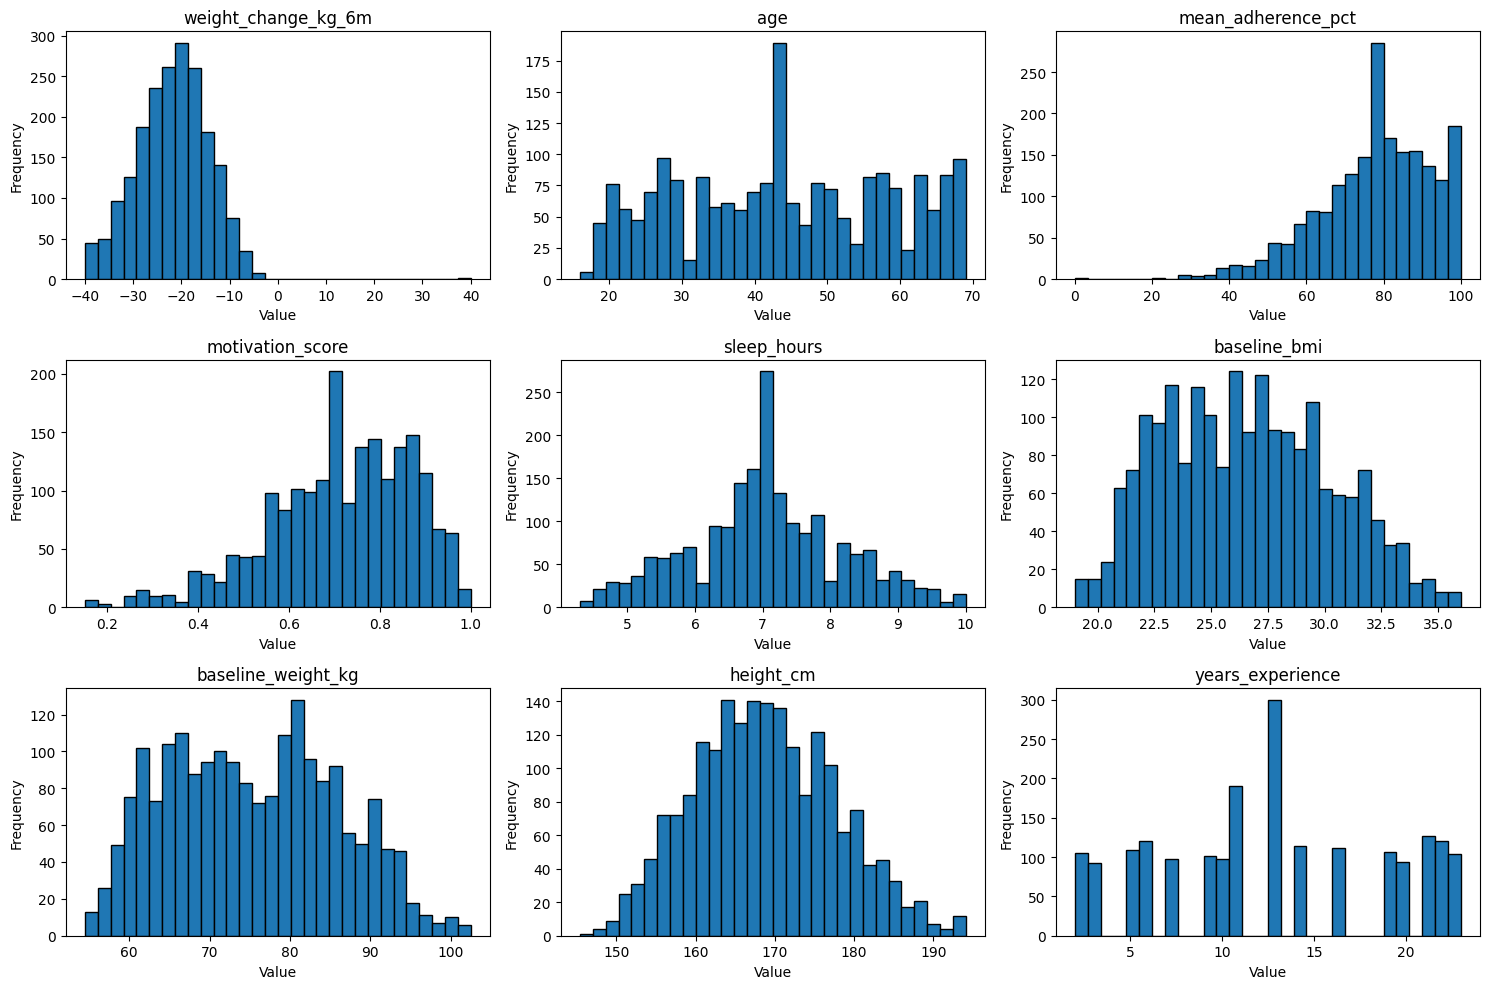

In [90]:
#Histogramas
import matplotlib.pyplot as plt

num_cols = ['weight_change_kg_6m', 'age', 'mean_adherence_pct',
            'motivation_score', 'sleep_hours', 'baseline_bmi',
            'baseline_weight_kg', 'height_cm', 'years_experience']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### **Matriz de Correlação**

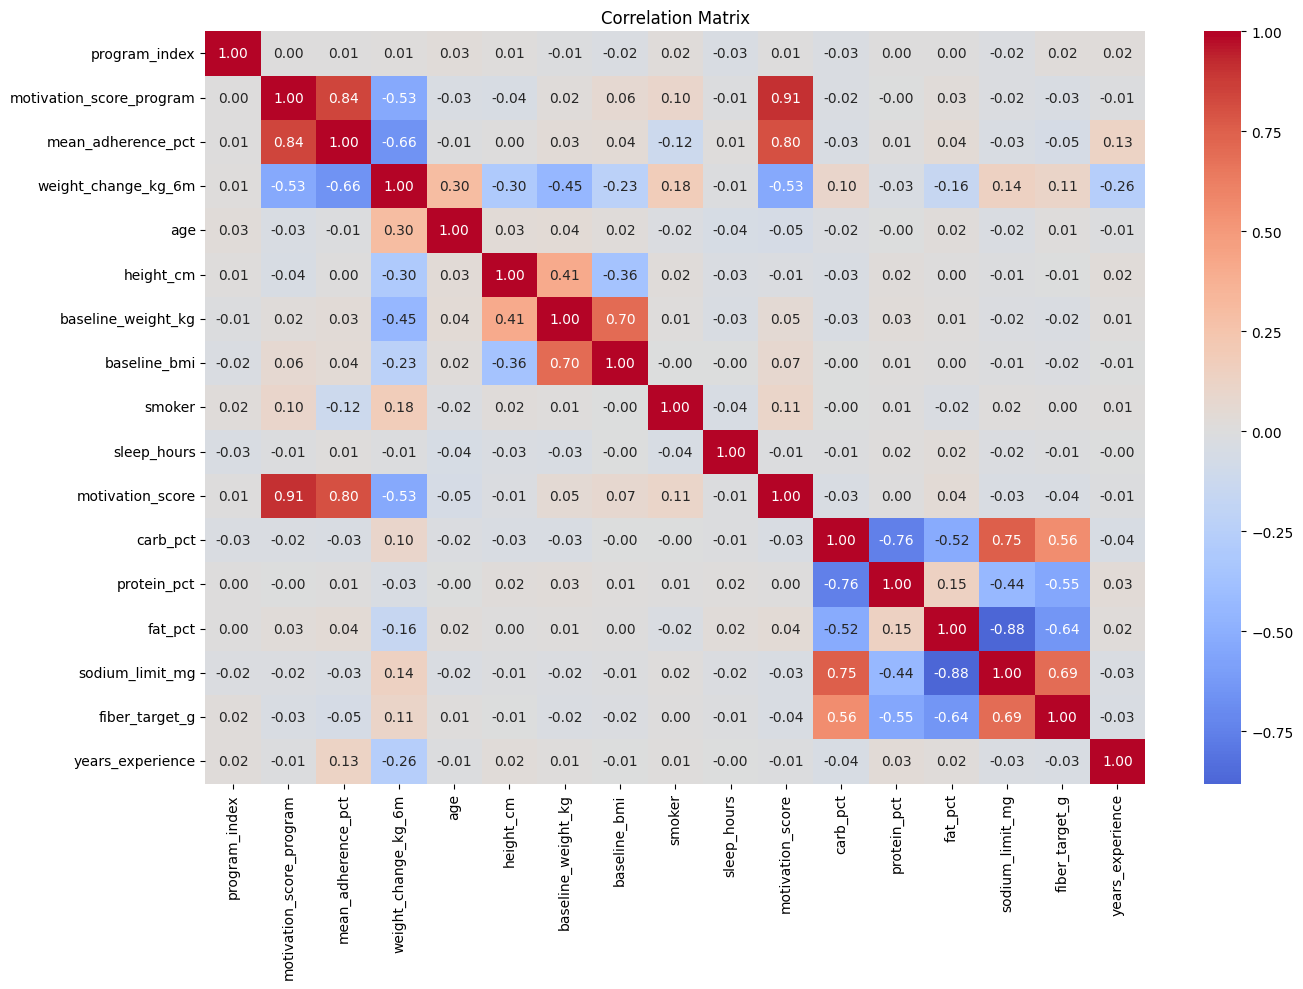

In [91]:
#Mapa de correlação
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

#### **Análise por Variáveis Categóricas**
Comparamos a distribuição do weight_change_kg_6m em função das variáveis categóricas para identificar grupos com comportamentos distintos.

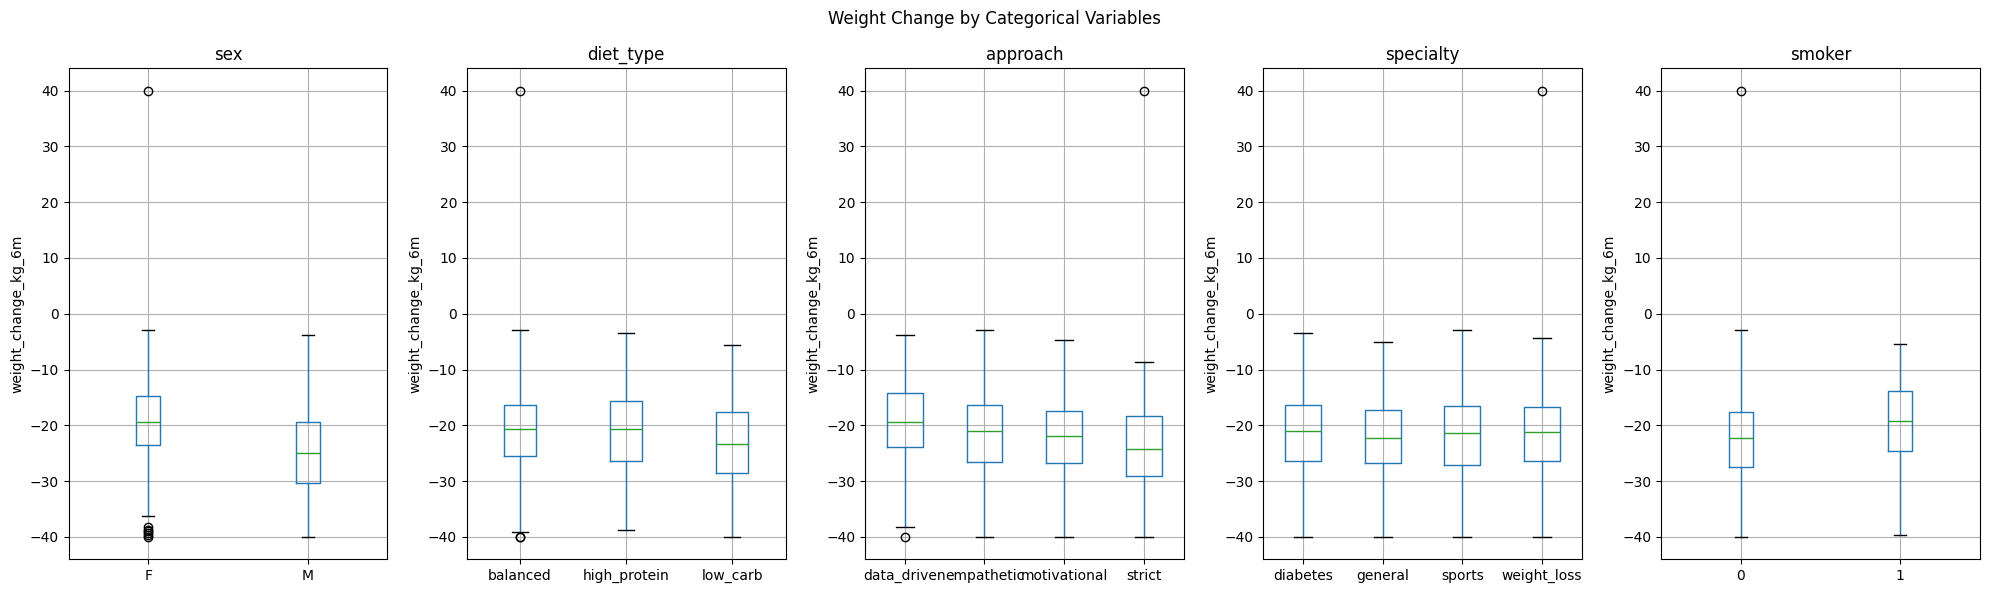

In [92]:
cat_cols = ['sex', 'diet_type', 'approach', 'specialty', 'smoker']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, col in enumerate(cat_cols):
    df.boxplot(column='weight_change_kg_6m', by=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('weight_change_kg_6m')

plt.suptitle('Weight Change by Categorical Variables')
plt.tight_layout()
plt.show()

#### **Scatter Plots: Relação com a Variável Alvo**
Analisamos a relação direta entre as variáveis numéricas mais relevantes e `weight_change_kg_6m`, para identificar tendências lineares.

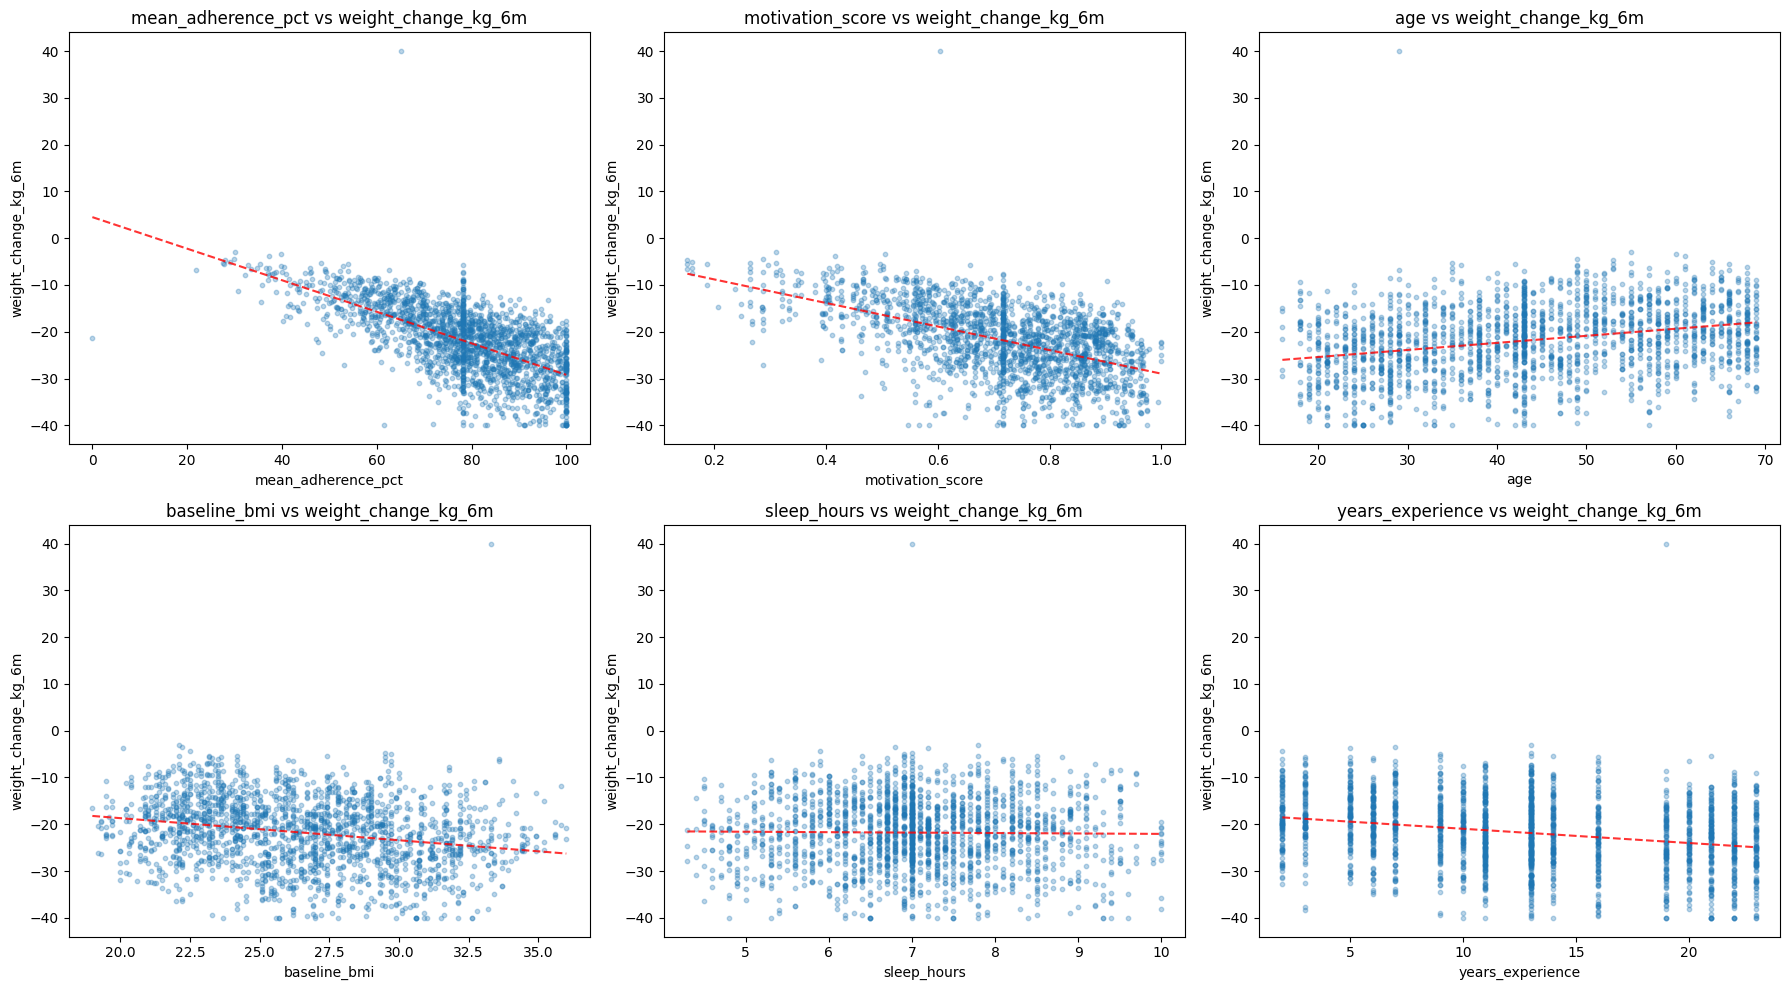

In [93]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

scatter_cols = ['mean_adherence_pct', 'motivation_score', 'age',
                'baseline_bmi', 'sleep_hours', 'years_experience']

for i, col in enumerate(scatter_cols):
    axes[i].scatter(df[col], df['weight_change_kg_6m'], alpha=0.3, s=10)
    z = np.polyfit(df[col], df['weight_change_kg_6m'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df[col]), p(sorted(df[col])), 'r--', alpha=0.8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('weight_change_kg_6m')
    axes[i].set_title(f'{col} vs weight_change_kg_6m')

plt.tight_layout()
plt.show()

#### **Síntese da EDA:**

| Dimensão | Principais conclusões |
|---|---|
| Variáveis mais preditivas | `mean_adherence_pct`, `motivation_score` |
| Variáveis do nutricionista | Relevância moderada; `specialty` e `approach` mostram alguma variação |
| Variáveis sem expressão preditiva | `age`, `sleep_hours`, `height_cm` |
| Redundâncias identificadas | `motivation_score` / `motivation_score_program`; `baseline_bmi` / `baseline_weight_kg` |
| Outliers tratados | IQR em 6 variáveis + limites de domínio em 4 variáveis |

### Identificação de Padrões

In [94]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Extração do mês a partir de patients.csv (record_created_at foi removido no processamento)
patients_raw = pd.read_csv("data/patients.csv")
patients_raw['month'] = pd.to_datetime(patients_raw['record_created_at']).dt.month
df = df.merge(patients_raw[['patient_id', 'month']], on='patient_id', how='left')
df['cold_month'] = df['month'].isin([11, 12, 1, 2]).astype(int)

# Apenas features comportamentais/numéricas para clustering
behavioral_features = [
    'mean_adherence_pct',
    'motivation_score',
    'age',
    'baseline_bmi',
    'sleep_hours',
    'years_experience',
    'cold_month'
]

cluster_df = df[behavioral_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)
print(f"Shape final para clustering: {cluster_df.shape}")

Shape final para clustering: (1993, 7)


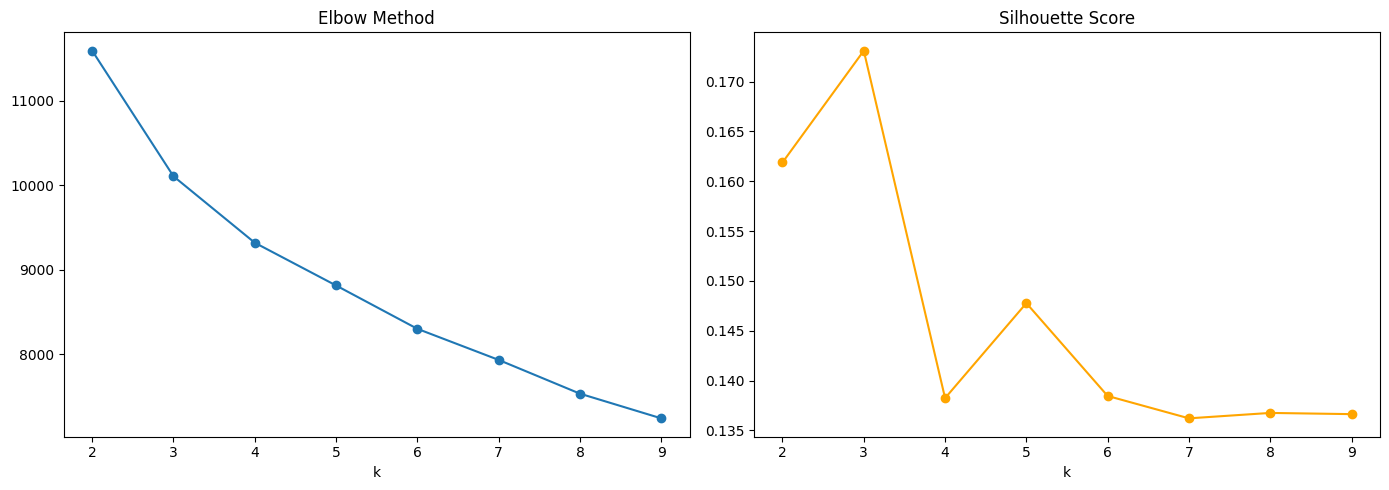

k ótimo pela silhueta: 3  (score=0.173)


In [95]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k')
axes[1].plot(K_range, sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

k_best = int(np.argmax(sil_scores)) + 2
print(f"k ótimo pela silhueta: {k_best}  (score={max(sil_scores):.3f})")

#### **K-MEANS**

In [98]:
km = KMeans(n_clusters=k_best, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster').agg({
    'weight_change_kg_6m': 'mean',
    'mean_adherence_pct': 'mean',
    'motivation_score': 'mean',
    'age': 'mean',
    'baseline_bmi': 'mean',
    'years_experience': 'mean',
    'diet_type': lambda x: x.mode()[0],
    'specialty': lambda x: x.mode()[0],
    'sex': lambda x: x.mode()[0]
})
print(cluster_profile)

         weight_change_kg_6m  mean_adherence_pct  motivation_score        age  \
cluster                                                                         
0                 -23.439591           82.227862          0.760238  43.133829   
1                 -14.747094           59.780378          0.518471  45.661323   
2                 -24.522176           85.107982          0.792972  43.406904   

         baseline_bmi  years_experience     diet_type specialty sex  
cluster                                                              
0           26.824907         12.908922      balanced    sports   F  
1           25.925852         12.010020  high_protein  diabetes   F  
2           26.708996         12.965481      balanced  diabetes   F  


#### **VISUALIZE**

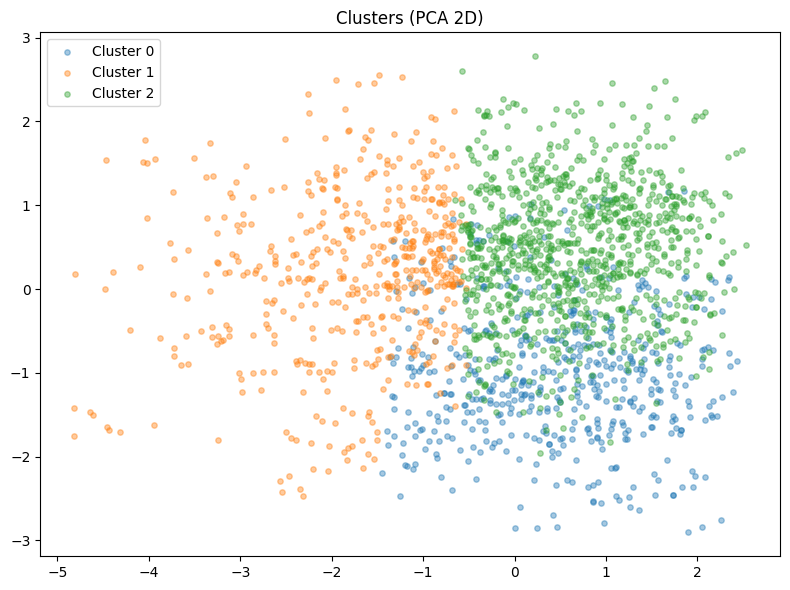

In [99]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for c in range(k_best):
    mask = df['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.4, s=15)
plt.title('Clusters (PCA 2D)')
plt.legend(); plt.tight_layout(); plt.show()

#### **Verificação de Padrões**

Após a identificação de clusters, verificamos diretamente dois padrões concretos nos dados.

Média de weight_change_kg_6m por grupo de idade e época do ano:
           Mês quente  Mês frio
age_group                      
< 50 anos      -22.94    -23.52
≥ 50 anos      -19.16    -19.53


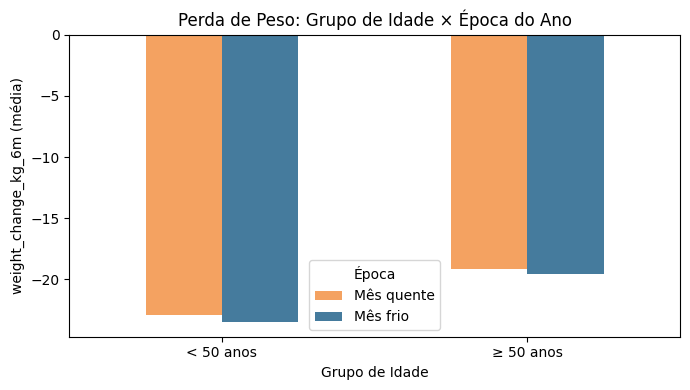

In [100]:
# Padrão 1: Indivíduos com menos de 50 anos perdem mais peso em meses frios?
df['age_group'] = pd.cut(df['age'], bins=[0, 50, 100], labels=['< 50 anos', '≥ 50 anos'])

pattern1 = df.groupby(['age_group', 'cold_month'], observed=True)['weight_change_kg_6m'].mean().unstack()
pattern1.columns = ['Mês quente', 'Mês frio']
print("Média de weight_change_kg_6m por grupo de idade e época do ano:")
print(pattern1.round(2))

pattern1.plot(kind='bar', figsize=(7, 4), color=['#f4a261', '#457b9d'])
plt.title('Perda de Peso: Grupo de Idade × Época do Ano')
plt.ylabel('weight_change_kg_6m (média)')
plt.xlabel('Grupo de Idade')
plt.xticks(rotation=0)
plt.legend(title='Época')
plt.tight_layout()
plt.show()

Distribuição de sexo por tipo de nutricionista:
sex               F      M
Não exigente  0.544  0.456
Exigente      0.551  0.449


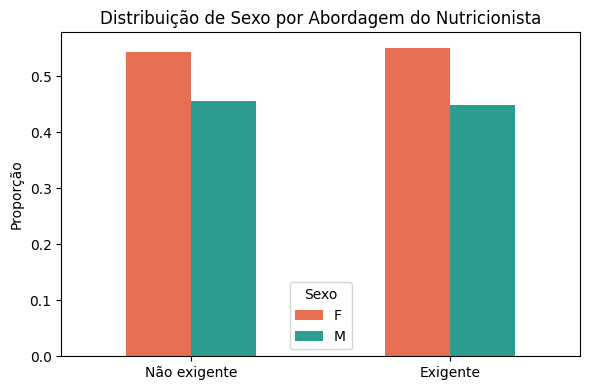

In [101]:
# Padrão 2: Nutricionistas mais exigentes têm mais pacientes do sexo masculino?
df['demanding'] = df['approach'].isin(['strict', 'data_driven'])

pattern2 = df.groupby('demanding', observed=True)['sex'].value_counts(normalize=True).unstack()
pattern2.index = ['Não exigente', 'Exigente']
print("Distribuição de sexo por tipo de nutricionista:")
print(pattern2.round(3))

pattern2.plot(kind='bar', figsize=(6, 4), color=['#e76f51', '#2a9d8f'])
plt.title('Distribuição de Sexo por Abordagem do Nutricionista')
plt.ylabel('Proporção')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

## **Aplicação de Modelos de Previsão**

Nesta secção aplicamos modelos de aprendizagem supervisionada para prever `weight_change_kg_6m`.


In [102]:
import pandas as pd

# Target e features
y = df['weight_change_kg_6m']

drop_cols = [
    'weight_change_kg_6m', 'motivation_score_program', 'baseline_weight_kg',
    'height_cm', 'cluster', 'month', 'cold_month', 'patient_id', 'nutritionist_id',
    'diet_id', 'program_index', 'diet_name', 'age_group', 'demanding'
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = pd.get_dummies(X, columns=['sex', 'diet_type', 'approach', 'specialty'])

print(X.shape)
print(X.columns.tolist())

(1993, 25)
['mean_adherence_pct', 'age', 'baseline_bmi', 'smoker', 'sleep_hours', 'motivation_score', 'carb_pct', 'protein_pct', 'fat_pct', 'sodium_limit_mg', 'fiber_target_g', 'years_experience', 'sex_F', 'sex_M', 'diet_type_balanced', 'diet_type_high_protein', 'diet_type_low_carb', 'approach_data_driven', 'approach_empathetic', 'approach_motivational', 'approach_strict', 'specialty_diabetes', 'specialty_general', 'specialty_sports', 'specialty_weight_loss']


In [103]:
from sklearn.model_selection import train_test_split

# Primeiro separa o test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Depois separa train (75% do restante = 60% total) e validation (25% = 20% total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (1195, 25), Validation: (399, 25), Test: (399, 25)


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# Conjuntos de treino+validação para treino final
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Linear Regression (baseline) — treino no conjunto completo
lr = LinearRegression()
lr.fit(X_train_full, y_train_full)

# Random Forest — tuning em X_train, treino final em X_train+X_val
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params,
                       cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
rf.fit(X_train_full, y_train_full)
print("RF best params:", rf_grid.best_params_)

# Gradient Boosting — tuning em X_train, treino final em X_train+X_val
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params,
                       cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gb_grid.fit(X_train, y_train)
gb = gb_grid.best_estimator_
gb.fit(X_train_full, y_train_full)
print("GB best params:", gb_grid.best_params_)

RF best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
GB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [107]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {'Model': name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R²': round(r2, 3)}

results = pd.DataFrame([
    evaluate('Linear Regression', lr, X_test, y_test),
    evaluate('Random Forest', rf, X_test, y_test),
    evaluate('Gradient Boosting', gb, X_test, y_test),
])
print(results)

               Model   RMSE    MAE     R²
0  Linear Regression  3.278  2.325  0.815
1      Random Forest  3.366  2.364  0.805
2  Gradient Boosting  3.243  2.089  0.819


Melhor modelo: Gradient Boosting


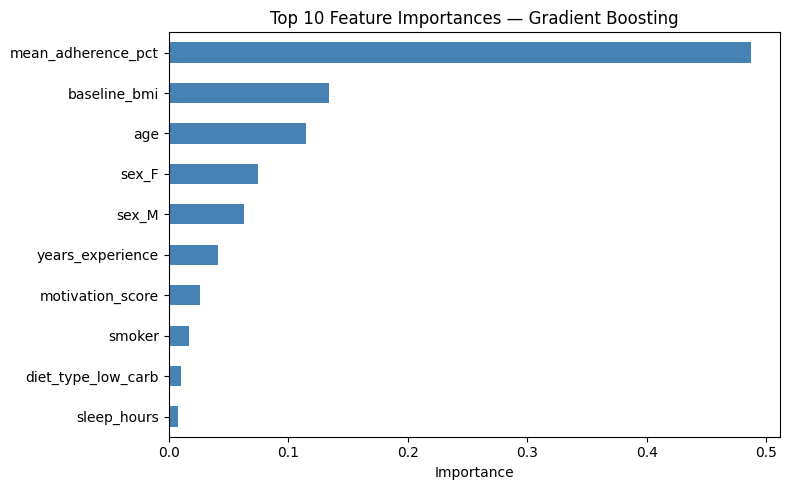

In [108]:
import matplotlib.pyplot as plt

# Seleciona o melhor modelo com base no menor RMSE (considera os 3)
model_map = {'Linear Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}
best_name = results.loc[results['RMSE'].idxmin(), 'Model']
best_model = model_map[best_name]
print(f"Melhor modelo: {best_name}")

# Feature importance — tree-based models têm feature_importances_, LR usa coeficientes
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns)

top10 = importances.sort_values(ascending=False).head(10)

top10.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top 10 Feature Importances — {best_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [109]:
perfil = {
    # --- Paciente ---
    'age': 18,
    'sex': 'M',               # 'M' ou 'F'
    'baseline_bmi': 25.8,
    'smoker': 0,              # 0 = não fumador | 1 = fumador
    'sleep_hours': 9.0,
    'motivation_score': 0.75, # 0.0 a 1.0
    'mean_adherence_pct': 75.0,
    # --- Dieta ---
    # Opções: 'balanced' | 'high_protein' | 'low_carb'
    'diet_type': 'low_carb',
    # --- Nutricionista ---
    # specialty: 'weight_loss' | 'general' | 'diabetes' | 'sports'
    # approach:  'motivational' | 'empathetic' | 'data_driven' | 'strict'
    'specialty': 'general',
    'approach': 'motivational',
    'years_experience': 10.0,
}

# ==========================================

# Construção da linha de previsão
diet = perfil['diet_type']
diet_means = df[df['diet_type'] == diet][['carb_pct','protein_pct','fat_pct','sodium_limit_mg','fiber_target_g']].mean()

sample = pd.DataFrame([{
    'age': perfil['age'],
    'baseline_bmi': perfil['baseline_bmi'],
    'smoker': perfil['smoker'],
    'sleep_hours': perfil['sleep_hours'],
    'motivation_score': perfil['motivation_score'],
    'mean_adherence_pct': perfil['mean_adherence_pct'],
    'carb_pct': diet_means['carb_pct'],
    'protein_pct': diet_means['protein_pct'],
    'fat_pct': diet_means['fat_pct'],
    'sodium_limit_mg': diet_means['sodium_limit_mg'],
    'fiber_target_g': diet_means['fiber_target_g'],
    'years_experience': perfil['years_experience'],
    'sex_F': 1 if perfil['sex'] == 'F' else 0,
    'sex_M': 1 if perfil['sex'] == 'M' else 0,
    'diet_type_balanced':     1 if diet == 'balanced' else 0,
    'diet_type_high_protein': 1 if diet == 'high_protein' else 0,
    'diet_type_low_carb':     1 if diet == 'low_carb' else 0,
    'diet_type_plant':        1 if diet == 'plant' else 0,
    'approach_motivational':  1 if perfil['approach'] == 'motivational' else 0,
    'approach_empathetic':    1 if perfil['approach'] == 'empathetic' else 0,
    'approach_data_driven':   1 if perfil['approach'] == 'data_driven' else 0,
    'approach_strict':        1 if perfil['approach'] == 'strict' else 0,
    'specialty_weight_loss':  1 if perfil['specialty'] == 'weight_loss' else 0,
    'specialty_general':      1 if perfil['specialty'] == 'general' else 0,
    'specialty_diabetes':     1 if perfil['specialty'] == 'diabetes' else 0,
    'specialty_sports':       1 if perfil['specialty'] == 'sports' else 0,
}]).reindex(columns=X.columns, fill_value=0)

pred = best_model.predict(sample)[0]

print(f"Dieta: {diet} | Especialidade: {perfil['specialty']} | Abordagem: {perfil['approach']}")
print(f"Perda de peso prevista: {pred:.2f} kg")

Dieta: low_carb | Especialidade: general | Abordagem: motivational
Perda de peso prevista: -31.58 kg
